In [1]:
!pip install plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 33.8 MB/s eta 0:00:0000:0100:01


In [2]:
!pip install anndata==0.8.0

In [3]:
!pip install -U kaleido

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 5.8 MB/s eta 0:00:00:00:0100:01


In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import plotly.express as px
import time
import matplotlib.patches as mpatches


In [37]:
sm = load_samap('Subclustering/PVH/sm_monogamous_PVH_02162026.pkl')

In [38]:
sm.sams['mg'].adata.obs['eq_supertype']

GCTGCGACAATGGATAL8TX_181019_01_D06    Nkx2-2
ACGGAGATCCTCAACCL8TX_180504_01_G01    Nkx2-2
AGGTCCGTCGTGGACCL8TX_181031_01_C07       Sst
CACACAACAAACCTACL8TX_181126_01_E11       Crh
CCTCAGTGTATTCGTGL8TX_181031_01_A07    Nkx2-2
                                       ...  
TTGTTCAGTCGAATGGL8TX_201016_01_A04       Avp
TTTACCATCAGCCTCTL8TX_200903_01_D12       Avp
TTTGATCCAAGGCAACL8TX_220331_01_D05       Avp
TTTGGAGGTCGCAGTCL8TX_190531_01_A02       Avp
TTTGTTGAGCTGGAGTL8TX_201210_01_D04       Avp
Name: eq_supertype, Length: 6390, dtype: category
Categories (7, object): ['Avp', 'Crh', 'Nkx2-2', 'Oxt', 'Sst', 'Trh', 'Ucn3']

In [40]:
orgs = ['mg','mo','mv','cc','cj','ri','rv']
pairs = [list(pair) for pair in itertools.combinations(orgs, 2)]
level = 'eq_supertype'
for org_one, org_two in pairs:
    print(org_one, org_two)
    df_plt = pd.DataFrame(columns = ['celltype_org','celltype_ref','mapping','num_cells'])
    a = 0
    keys = {org_one:level,org_two:level}
    D,MappingTable = get_mapping_scores(sm,keys)

    lim_MappingTable = MappingTable.filter(like=org_one + '_')
    lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(org_two + '_')]
    lim_MappingTable.to_csv('Subclustering/' + org_one + '_' + org_two + '_mapping_PVH_clusters.csv')

mg mo
mg mv
mg cc
mg cj
mg ri
mg rv
mo mv
mo cc
mo cj
mo ri
mo rv
mv cc
mv cj
mv ri
mv rv
cc cj
cc ri
cc rv
cj ri
cj rv
ri rv


In [6]:
org_one = 'cc'
org_two = 'rv'
level = 'eq_supertype'
keys = {org_one:level,org_two:level}
D,MappingTable = get_mapping_scores(sm,keys)

lim_MappingTable = MappingTable.filter(like=org_one)
lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(org_two)]

sankey_plot(MappingTable, align_thr=0.05, bgcolor = 'white')

:Sankey   [source,target]   (Value)

In [41]:
#all dfs load
ct = 'PVH'
organisms = ['mg', 'mo', 'mv', 'cc', 'cj', 'ri', 'rv']
level = 'eq_supertype'

# Generate all unique pairs and read CSVs once
mapping = {}
for i, org1 in enumerate(organisms):
    for j, org2 in enumerate(organisms):
        key = f"{org1}_{org2}".upper()
        if i == j:
            uct = sm.sams[org1].adata.obs['eq_supertype'].unique()
            mapping[key] = pd.DataFrame(data = np.eye(len(uct)),index = [org1 + '_' + i for i in uct], columns = [org1 + '_' + i for i in uct])
        if i < j:
            # Read the file for this pair
            df = pd.read_csv(f'Subclustering/{ct}/Mono/{org1}_{org2}_mapping_{ct}_clusters.csv', 
                             index_col='Unnamed: 0')
            mapping[key] = df
        else:
            # Derive from the transpose of the already-read file
            key = f"{org1}_{org2}".upper()
            reverse_key = f"{org2}_{org1}".upper()
            mapping[key] = mapping[reverse_key].T

In [42]:
organism_rows = {}
for org1 in organisms:
    dfs = [mapping[f"{org1}_{org2}".upper()] for org2 in organisms]
    organism_rows[org1.upper()] = pd.concat(dfs)

In [43]:
pvh_mapping = pd.concat([organism_rows[i.upper()] for i in organisms], axis = 1)

<AxesSubplot:>

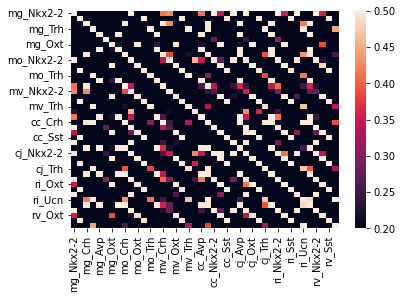

In [44]:
sns.heatmap(pvh_mapping, vmin = .2, vmax = .5)

In [23]:
pvh_mapping

,mg_Nkx2-2,mg_Sst,mg_Crh,mg_Trh,mg_Avp,mg_Ucn3,mg_Oxt,mo_Avp,mo_Crh,mo_Nkx2-2,...,ri_Nkx2-2,ri_Oxt,ri_Sst,ri_Trh,ri_Ucn,rv_Avp,rv_Nkx2-2,rv_Oxt,rv_Sst,rv_Ucn
mg_Nkx2-2,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.005669,0.890682,...,0.719521,0.352852,0.000244,0.533157,0.000000,0.000000,0.636028,0.358825,0.009321,0.000000
mg_Sst,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.014019,0.009626,...,0.034809,0.006935,0.777206,0.002872,0.001003,0.020906,0.021664,0.008031,0.661111,0.003637
mg_Crh,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.002648,0.879392,0.008404,...,0.017277,0.000682,0.076940,0.008273,0.418678,0.556541,0.022835,0.002430,0.031590,0.152211
mg_Trh,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.150051,0.004649,...,0.005626,0.001941,0.010620,0.000968,0.521285,0.087362,0.020484,0.000541,0.116784,0.446250
mg_Avp,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.973385,0.011107,0.000711,...,0.001580,0.040805,0.000013,0.005516,0.000023,0.634175,0.001497,0.022047,0.000000,0.000000
mg_Ucn3,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.162481,...,0.308210,0.009766,0.004509,0.026217,0.000079,0.000000,0.071385,0.000699,0.002712,0.005075
mg_Oxt,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.221845,0.000319,0.006879,...,0.007810,0.588297,0.000000,0.025856,0.000000,0.148364,0.007427,0.388646,0.000464,0.000000
mo_Avp,0.000000,0.000000,0.002648,0.000000,0.973385,0.000000,0.221845,1.000000,0.000000,0.000000,...,0.000302,0.001466,0.000000,0.000179,0.000000,0.646462,0.004062,0.000000,0.000000,0.000000
mo_Crh,0.005669,0.014019,0.879392,0.150051,0.011107,0.000000,0.000319,0.000000,1.000000,0.000000,...,0.006250,0.000407,0.033354,0.000000,0.433924,0.591941,0.004305,0.000000,0.022664,0.254984
mo_Nkx2-2,0.890682,0.009626,0.008404,0.004649,0.000711,0.162481,0.006879,0.000000,0.000000,1.000000,...,0.705063,0.172605,0.013094,0.495709,0.011117,0.002992,0.650770,0.224334,0.063948,0.018496


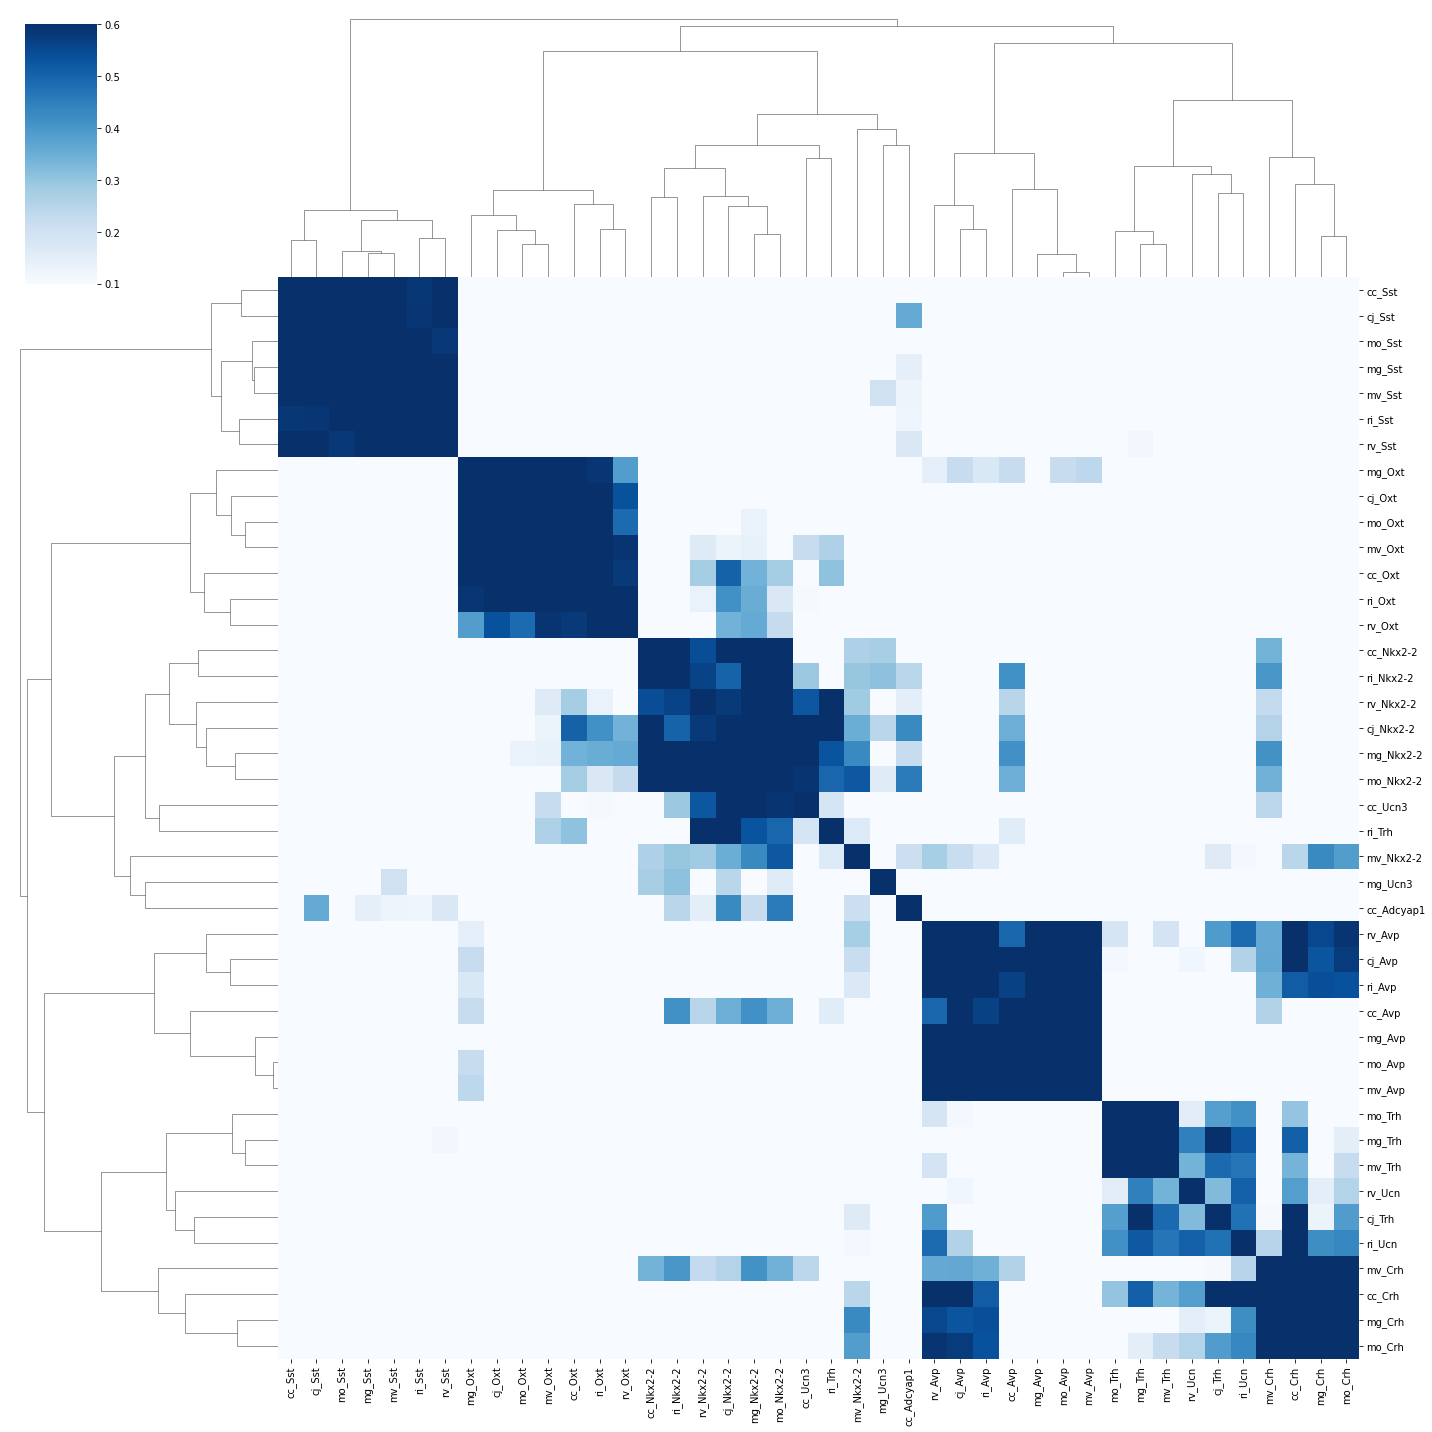

In [45]:
g =sns.clustermap(pvh_mapping, vmax = .6, vmin = .1,cmap = 'Blues',figsize=(20,20))

In [46]:
reorder_row = g.dendrogram_row.reordered_ind
reorder_col = g.dendrogram_col.reordered_ind

In [47]:
pvh_mapping_ord = pvh_mapping.loc[pvh_mapping.index[reorder_row],:]
pvh_mapping_ord = pvh_mapping_ord.loc[:,pvh_mapping.columns[reorder_col]]

In [49]:
#changed colors PVH
category_one = [i[:2] for i in pvh_mapping.index[reorder_row]]
category_two = [i[3:] for i in pvh_mapping.index[reorder_row]]
color_map_one = {"mg": "#C9A185", "mo": "#C9A0DC", 'mv':'#ff7f0e',
                 'cc':'#9467bd',"cj": "#fa9189",
                'ri':'#bcbd22','rv':'#17becf'}
color_map_two = {'Avp':'#4DAE49',
                   'Avp + Sst':'#ED82B4',
                   'Crh': '#F47E20',
                   'Nkx2-2':'#D3D3D3',
                   'Nkx2-2 + Nr4a2':'#D3D3D3',
                   'Oxt':'#E11F26',
                   'Sst':'#ED82B4',
                   'Trh':'#974F9E',
                   'Ucn':'#FFD421',
                   'Ucn3':'#A65628',
                   'Adcyap1':'#3E8E93',
                   'nkx2-2':'#D3D3D3',
                   'unlabeled':'#D3D3D3'}

col_colors = pd.DataFrame({
    "Organism": pd.Series(category_one, index=pvh_mapping_ord.columns).map(color_map_one),
    "Celltype": pd.Series(category_two, index=pvh_mapping_ord.columns).map(color_map_two),
})

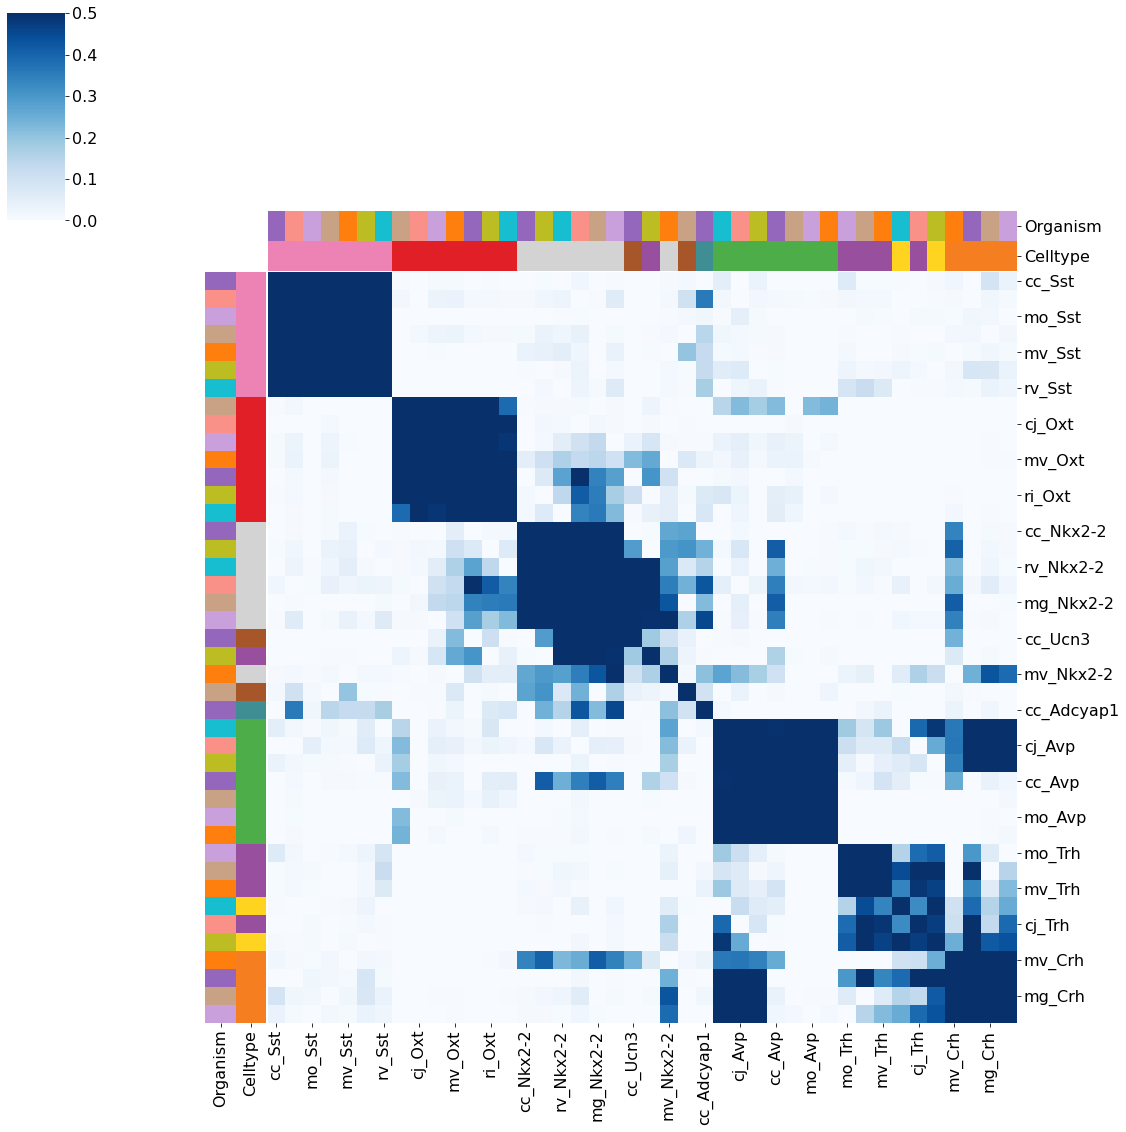

In [51]:
plt.rcParams['font.size'] = 16
g =sns.clustermap(pvh_mapping, vmax = .5, cmap = 'Blues',figsize=(16,16),col_colors = col_colors, row_colors = col_colors)
g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)
plt.savefig('Figures/Figures_02202026/Monoorgs_PVH_heatmap.svg')
plt.savefig('Figures/Figures_02202026/Monoorgs_PVH_heatmap.png', dpi = 600)

In [68]:
pvh_mapping.shape[0]

28

In [55]:
sam = SAM()
sam.load_data('Active_SAM_joined/SAM_RV_joined_NN_geneexp_cleaned_01252026.h5ad')
print(len(sam.adata))

26923


In [73]:
with open('parent_dict.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [56]:
numcellstot = {'mo':73955,'cj':55757,'ac':36469,'xt':39056,'dr':68570,'mv':69407,'cc':46482,'ri':61387,'rv':26923}

In [58]:
allct = set(sm.sams['mg'].adata.obs['eq_supertype']) |set(sm.sams['mo'].adata.obs['eq_supertype']) | set(sm.sams['mv'].adata.obs['eq_supertype']) | set(sm.sams['cc'].adata.obs['eq_supertype']) | set(sm.sams['cj'].adata.obs['eq_supertype']) | set(sm.sams['ri'].adata.obs['eq_supertype']) | set(sm.sams['rv'].adata.obs['eq_supertype'])

In [62]:
org_names = {
    'mo': 'Prairie Vole',
    'mv': 'Meadow Vole',
    'cc': 'King Quail',
    'cj': 'Japanese Quail',
    'ri': 'Imitator Frog',
    'rv': 'Variabilis Frog'
}

rows = []
for item in allct:
    print(item)
    for org_key, org_name in org_names.items():
        adata = sm.sams[org_key].adata
        if item in adata.obs['eq_supertype'].unique():
            frac = len(adata[adata.obs['eq_supertype'] == item]) / numcellstot[org_key]
        else:
            frac = 0
        rows.append({'Organism': org_name, 'Celltype': item, 'Fraccells': frac})

df = pd.DataFrame(rows)

Trh
Ucn3
Nkx2-2
Adcyap1
Sst
Ucn
Oxt
Crh
Avp


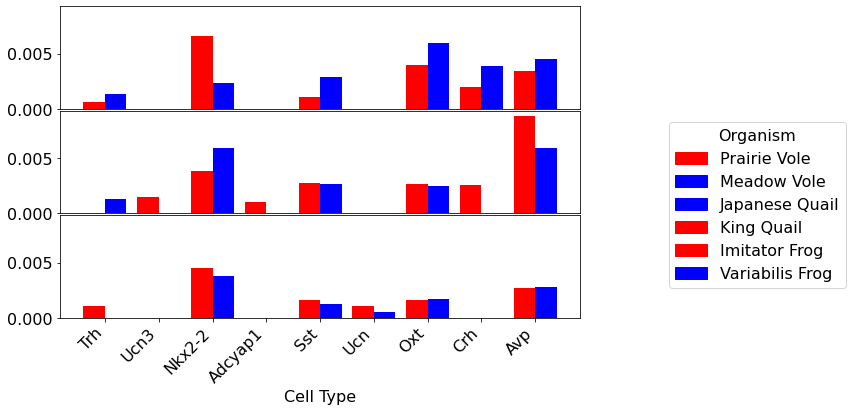

In [65]:
pairs = [
    ('Prairie Vole', 'Meadow Vole'),
    ('King Quail', 'Japanese Quail'),
    ('Imitator Frog', 'Variabilis Frog')
]

# Monogamous = red tones, Polygamous = blue/cool tones
pair_colors = {
    'Prairie Vole':    'red',  # red
    'Meadow Vole':     'blue',  # blue
    'Japanese Quail':  'blue',  # orange-red
    'King Quail':      'red',  # cyan
    'Imitator Frog':   'red',  # pink-red
    'Variabilis Frog': 'blue',  # purple
}

celltypes = df['Celltype'].unique()
x = np.arange(len(celltypes))
bar_width = 0.4
n_pairs = len(pairs)

fig, axes = plt.subplots(n_pairs, 1, figsize=(10, 2*n_pairs), sharey=True)

for i, (org1, org2) in enumerate(pairs):
    data1 = df[df['Organism'] == org1].set_index('Celltype')
    data2 = df[df['Organism'] == org2].set_index('Celltype')

    axes[i].bar(x - bar_width/2, data1.reindex(celltypes)['Fraccells'],
                width=bar_width, color=pair_colors[org1], label=org1)
    axes[i].bar(x + bar_width/2, data2.reindex(celltypes)['Fraccells'],
                width=bar_width, color=pair_colors[org2], label=org2)

    if i != n_pairs - 1:
        axes[i].set_xticks([])
    else:
        axes[i].set_xticks(x)
        axes[i].set_xticklabels(celltypes, rotation=45, ha='right')
        axes[i].set_xlabel('Cell Type')

legend_handles = [mpatches.Patch(color=color, label=org) for org, color in pair_colors.items()]
fig.legend(handles=legend_handles, loc='center right', bbox_to_anchor=(1.2, 0.5),
           title='Organism', frameon=True)

plt.tight_layout()
plt.subplots_adjust(hspace=0.02, right=0.82)
plt.savefig('Figures/Figures_02202026/Fraccellsallcells_PVH_monoorgs.svg', bbox_inches='tight')
plt.show()

In [159]:
df = pd.DataFrame(columns = ['Organism','Celltype','Fraccells']).astype(object)
a = 0
for item in allct:
    print(item)
    if item in sm.sams['mg'].adata.obs['eq_supertype'].unique():
        df.loc[a,:] = ['Mouse',item,len(sm.sams['mg'].adata[sm.sams['mg'].adata.obs['eq_supertype'] == item])/len(sm.sams['mg'].adata)]
        a += 1
    else:
        df.loc[a,:] = ['Mouse',item,0]
        a += 1
    
    if item in sm.sams['mo'].adata.obs['eq_supertype'].unique():
        df.loc[a,:] = ['Prarie Vole',item,len(sm.sams['mo'].adata[sm.sams['mo'].adata.obs['eq_supertype'] == item])/len(sm.sams['mo'].adata)]
        a += 1
    else:
        df.loc[a,:] = ['Prarie Vole',item,0]
        a += 1
        
    if item in sm.sams['cj'].adata.obs['eq_supertype'].unique():
        df.loc[a,:] = ['Japanese Quail',item,len(sm.sams['cj'].adata[sm.sams['cj'].adata.obs['eq_supertype'] == item])/len(sm.sams['cj'].adata)]
        a += 1
    else:
        df.loc[a,:] = ['Japanese Quail',item,0]
        a += 1
        
    if item in sm.sams['ac'].adata.obs['eq_supertype'].unique():
        df.loc[a,:] = ['Green Anole',item,len(sm.sams['ac'].adata[sm.sams['ac'].adata.obs['eq_supertype'] == item])/len(sm.sams['ac'].adata)]
        a += 1
    else:
        df.loc[a,:] = ['Green Anole',item,0]
        a += 1
        
    if item in sm.sams['xt'].adata.obs['eq_supertype'].unique():
        df.loc[a,:] = ['Xenopus',item,len(sm.sams['xt'].adata[sm.sams['xt'].adata.obs['eq_supertype'] == item])/len(sm.sams['xt'].adata)]
        a += 1
    else:
        df.loc[a,:] = ['Xenopus',item,0]
        a += 1
        
    if item in sm.sams['dr'].adata.obs['eq_supertype'].unique():
        df.loc[a,:] = ['Zebrafish',item,len(sm.sams['dr'].adata[sm.sams['dr'].adata.obs['eq_supertype'] == item])/len(sm.sams['dr'].adata)]
        a += 1
    else:
        df.loc[a,:] = ['Zebrafish',item,0]
        a += 1

Avp
Ucn
Crh
Sst
adcyap1
Ucn3
Oxt
Trh
Nkx2-2


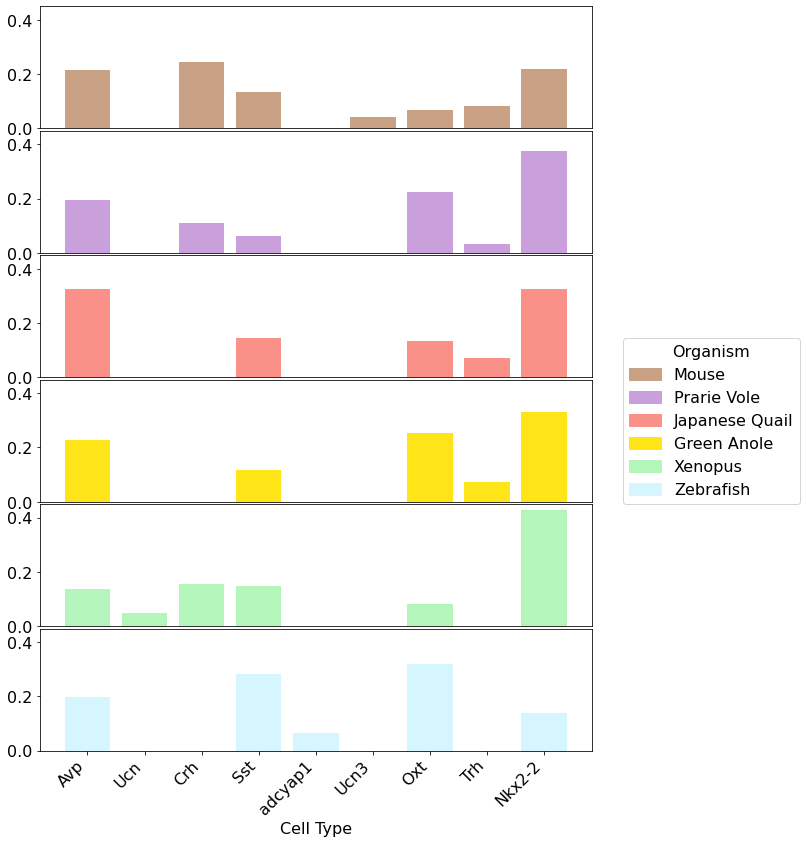

In [160]:
organisms = df['Organism'].unique()
n_organisms = len(organisms)

# Create subplots
fig, axes = plt.subplots(n_organisms,1, figsize=(10, 2*n_organisms), sharey=True)

# If only one organism, axes won't be an array
if n_organisms == 1:
    axes = [axes]

# Plot each organism
org_colors = ["#C9A185","#C9A0DC","#fa9189","#ffe518","#b4f5bc","#d6f6ff"]
for i, organism in enumerate(organisms):
    # Filter data for this organism
    organism_data = df[df['Organism'] == organism]
    
    # Create bar plot
    axes[i].bar(organism_data['Celltype'], organism_data['Fraccells'], color = org_colors[i])
    if i != n_organisms-1:
        axes[i].set_xticklabels([])
        axes[i].set_xticks([])
    if i == n_organisms-1:
        axes[i].set_xlabel('Cell Type')
        axes[i].tick_params(axis='x', rotation=45)
        plt.setp(axes[i].get_xticklabels(), ha = 'right')
        
legend_handles = [mpatches.Patch(color=org_colors[i], label=organisms[i]) for i in range(n_organisms)]
fig.legend(handles=legend_handles, loc='center right', bbox_to_anchor=(1.15, 0.5), 
           title='Organism', frameon=True)
plt.tight_layout()
plt.subplots_adjust(hspace = 0.02, right=0.85)
plt.savefig('Figures/Figures_02202026/FraccellsPVH_PVH_hypoorgs.svg')
plt.show()

In [161]:
sm.sams['xt'].adata.obs['eq_supertype'].value_counts()

Nkx2-2    254
Crh        93
Sst        88
Avp        81
Oxt        49
Ucn        28
Name: eq_supertype, dtype: int64

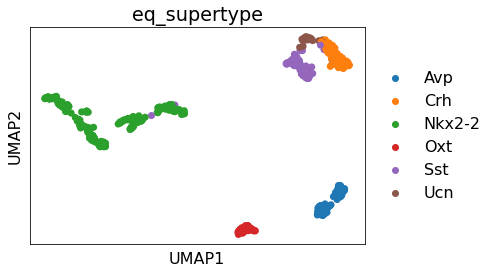

In [162]:
sc.pl.umap(sm.sams['xt'].adata, color = 'eq_supertype')

In [166]:
m = pd.read_csv('BLASTMAPPING/maps/active_maps/hypo_proj/xtmg/mg_to_xt.txt', delimiter = '\t', header = None)

In [171]:
m[m[0] == 'Crh']

,0,1,2,3,4,5,6,7,8,9,10,11
215896,Crh,ENSXETG00000040673,95.122,41,2,0,442,564,690,812,2.070000e-27,91.3
215897,Crh,ENSXETG00000035344,95.122,41,2,0,442,564,909,1031,3.080000e-27,91.3
215898,Crh,trim55,95.122,41,2,0,442,564,3046,2924,3.620000e-26,91.3
215899,Crh,UCN,48.780,41,21,0,442,564,578,700,1.600000e-07,55.1


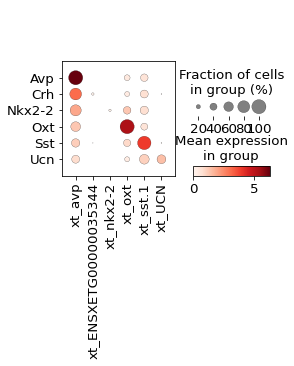

In [173]:
sc.pl.dotplot(sm.sams['xt'].adata,var_names = ['xt_avp','xt_ENSXETG00000035344','xt_nkx2-2','xt_oxt','xt_sst.1','xt_UCN'],groupby = 'eq_supertype')